# Example calculation 

In this example we showcase the functionality of adding measurement points to the model. Measurement points can be added to monitor the temperature at position (x,y) in the environment.

Measurement points can be added to `ModelSoil` only. To add a measurement point, we start by constructing a static environment and setting up a model. See [example_calculation.ipynb](example_calculation.ipynb) for a step by step guide on setting up a model.

In [ ]:
from datetime import datetime

import numpy as np
import pandas as pd

from cable_thermal_model import CableLayer, CablePosition, ModelFactory, StaticEnvSoil
from cable_thermal_model.cable.schemas.circuit_schemas import CircuitInSoilFromCableIdInputSchema

static_env = StaticEnvSoil()

circuit_input_1 = CircuitInSoilFromCableIdInputSchema(
    x=0.0,
    y=-1,
    circuit_name="circuit_1",
    cable_id="GPLK 10/10 kV 3x185 Al",
    cable_source_file_path="../../data/example_cables.csv",
)
static_env.add_circuit_from_cable_id(circuit_input_1)

# In this case we use a scenario that lasts for a week with a step size of 1 hour.
START_DATE = datetime(2026, 1, 1)
DAYS_TO_SIMULATE = 7

scenario = pd.DataFrame(
    index=pd.date_range(start=START_DATE, end=START_DATE + pd.Timedelta(days=DAYS_TO_SIMULATE), freq="1h")
)

# We set the load of the circuit to oscillate between 50 and 350A with a period of 24 hours.
scenario["load_circuit_1"] = 200 + 150 * np.sin(2 * np.pi * scenario.index.hour / 24)
scenario["ambient_temperature"] = 15  # Ambient temperature is assumed to be constant at 15 degrees Celsius.
scenario["soil_thermal_resistivity"] = 0.75  # Soil thermal resistivity is assumed to be constant at 0.75 mK/W.
scenario["soil_thermal_capacity"] = 2e6  # Soil thermal capacity is assumed to be constant at 2e6 J/(m³K).

model = ModelFactory.create_model(static_env=static_env, scenario=scenario)

With a model set, we can add one or multiple measurement points. The measurement keys can be used to retrieve the temperature profile after running the model.

In [ ]:
measurement_point_key1 = model.add_measurement_point(x=0.1, y=-1.0)
measurement_point_key2 = model.add_measurement_point(x=0.3, y=-1.0)

Now that the measurement points are defined, the model can be executed to compute the temperature profile over time.

The simulation output is stored in `solution`, and the temperature time series are available in `temperature_result`.  
This includes cable temperatures (e.g., conductor and sheath) as well as temperatures at the added measurement points.

In [ ]:
solution = model.run()
temperature_result = solution.result

The temperature profile at a measurement point can be retrieved using the forementioned keys.

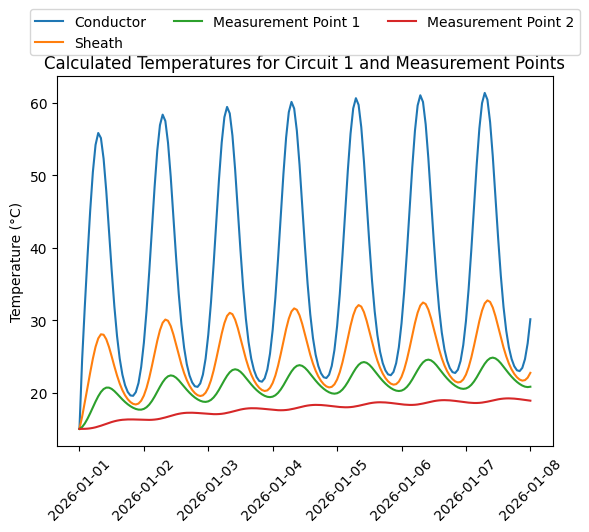

In [ ]:
import matplotlib.pyplot as plt

# Plot the measurement points together with conductor and sheath temperatures.
x = temperature_result.index
series = [
    temperature_result["circuit_1"][CablePosition.Single][CableLayer.Conductor],
    temperature_result["circuit_1"][CablePosition.Single][CableLayer.Sheath],
    temperature_result[measurement_point_key1],
    temperature_result[measurement_point_key2],
    model.scenario["ambient_temperature"],
]
labels = [
    "Conductor",
    "Sheath",
    "Measurement Point 1",
    "Measurement Point 2",
    "Ambient",
]

for y, label in zip(series, labels, strict=True):
    plt.plot(x, y, label=label)

plt.ylabel("Temperature (°C)")
plt.title("Calculated Temperatures for Circuit 1 and Measurement Points")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()